<a href="https://colab.research.google.com/github/blueberrycrumble/AIFFEL_quest_cr/blob/master/DLThon/DLThon_jellyfish_wip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL톤 해파리 분류기
아이펠 코어 12기 팀: 해파리지앵  
@author: Hyeseung Lee  
Created: 2025-04-01  

## Introduction

## 0. 데이터셋 준비

In [13]:
pip install --force-reinstall -v "Pillow==9.5.0"

Using pip 24.1.2 from /usr/local/lib/python3.11/dist-packages/pip (python 3.11)
  Obtaining dependency information for Pillow==9.5.0 from https://files.pythonhosted.org/packages/3d/59/e6bd2c3715ace343d9739276ceed79657fe116923238d102cf731ab463dd/Pillow-9.5.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 28.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


In [1]:
# pip install kaggle

In [2]:
# 캐글 API 키로 로그인
# import kagglehub
# kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
# 데이터셋을 다운로드해서 캐시에 저장
# kagglehub.dataset_download('anshtanwar/jellyfish-types')

100%|██████████| 25.5M/25.5M [00:00<00:00, 116MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/anshtanwar/jellyfish-types/versions/16'

In [ ]:
# 원본 데이터셋 경로와 구글 드라이브 경로
# source_path = "/root/.cache/kagglehub/datasets/anshtanwar/jellyfish-types/versions/16"
# target_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset"

# # 절대 경로 설정
# data_path = os.path.join(source_path, "Train_Test_Valid")
# !mkdir -p "{target_path}"

# # 필요한 폴더만 복사
# if os.path.exists(data_path):
#     !cp -r "{data_path}" "{target_path}/"
#     print(f"Train_Test_Valid 폴더만 복사 완료")
# else:
#     print(f"{data_path} 폴더가 원본에 존재하지 않습니다.")

# # 경로 내 파일 확인
# files = os.listdir(data_path)
# !ls -la {target_path}
# print(files)

Train_Test_Valid 폴더만 복사 완료
total 4
drwx------ 5 root root 4096 Apr  1 06:21 Train_Test_Valid
['test', 'Train', 'valid']




---



## 1. EDA

In [21]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from tqdm import tqdm
import warnings
from PIL import Image
import random

import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [2]:
# 데이터셋의 경로 설정
data_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid"
train_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train"
val_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/valid"
test_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/test"

print(train_path)
print(val_path)
print(test_path)

/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/valid
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/test


In [3]:
# 폴더 이미지 카운트
img_counts = []

# Train 폴더 내 모든 서브폴더 확인
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder) # 서브폴더 경로

    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        img_counts.append({"Folder": folder,
                              "Image_Count": num_images})
# 데이터프레임으로 변환
df_counts = pd.DataFrame(img_counts)
print(df_counts)

                    Folder  Image_Count
0           Moon_jellyfish          150
1         barrel_jellyfish          150
2           blue_jellyfish          150
3        compass_jellyfish          150
4     lions_mane_jellyfish          150
5  mauve_stinger_jellyfish          150


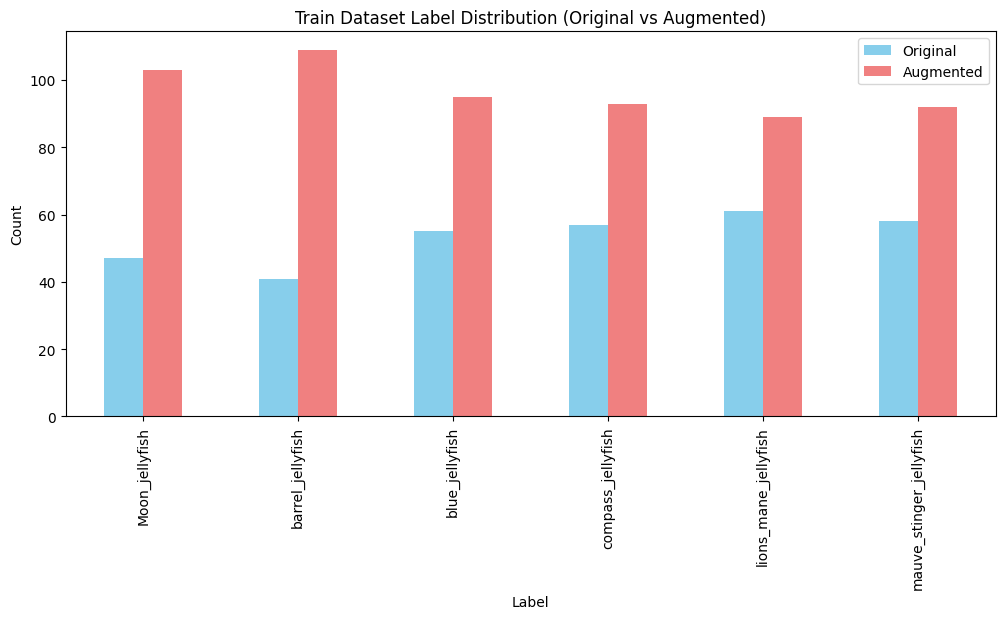

In [4]:
# 라벨 분포 확인 (Augmentation 데이터와 원본 이미지 구분)
def count_labels(dataset_path):
    label_counts = {}
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            # 폴더 내 이미지 파일 확인
            original_count = 0
            augmented_count = 0
            for filename in os.listdir(folder_path):
                if filename.startswith("aug-"):
                    augmented_count += 1
                else:
                    original_count += 1
            # 라벨별 original, augmented 개수 저장
            label_counts[folder] = {"Original": original_count, "Augmented": augmented_count}
    return label_counts

# Train 라벨 개수 집계
train_counts = count_labels(train_path)

# 데이터프레임 변환
df_train = pd.DataFrame.from_dict(train_counts, orient='index')
df_train = df_train.reset_index().rename(columns={"index": "Label"})

# 라벨 분포 시각화 (Original vs Augmented)
fig, ax = plt.subplots(figsize=(12, 5))
df_train.plot(kind="bar", x="Label", y=["Original", "Augmented"], ax=ax, color=["skyblue", "lightcoral"])
ax.set_title("Train Dataset Label Distribution (Original vs Augmented)")
ax.set_ylabel("Count")
plt.show()

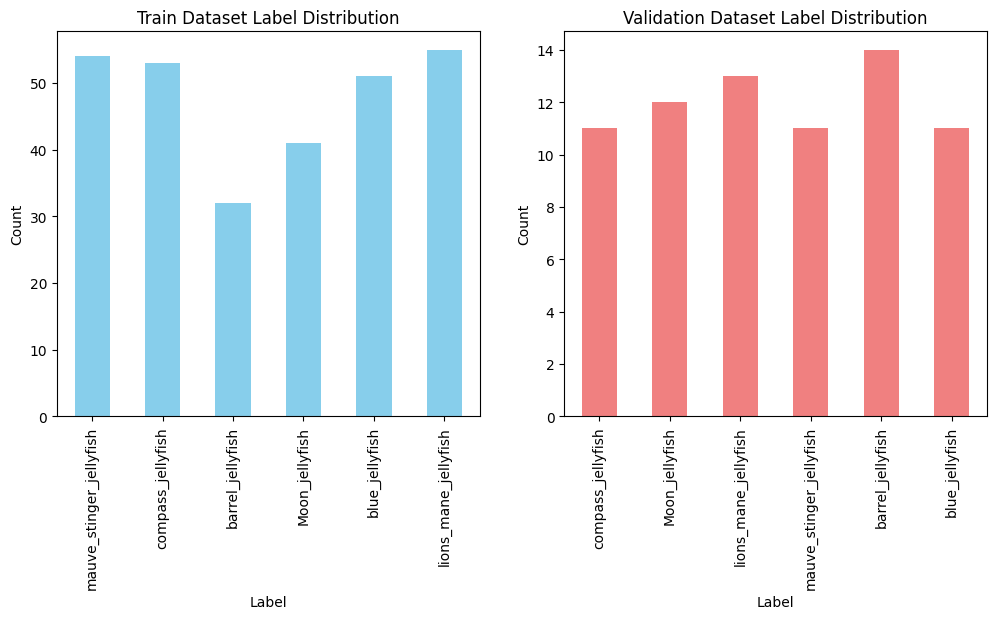

In [29]:
# 라벨 분포 확인
def count_labels(dataset_path):
    label_counts = {}
    for folder in os.listdir(dataset_path):
        # dataset_path를 사용하여 폴더 경로 생성
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):  # 폴더인지 확인
            label_counts[folder] = int(len(os.listdir(folder_path)))  # 해당 폴더 내 파일 개수 저장
    return label_counts

# Train & Validation 라벨 개수 집계
train_counts = count_labels(train_path)
val_counts = count_labels(val_path)

# 데이터프레임 변환
df_train = pd.DataFrame(list(train_counts.items()), columns=["Label", "Count"])
df_val = pd.DataFrame(list(val_counts.items()), columns=["Label", "Count"])

# 라벨 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_train.plot(kind="bar", x="Label", y="Count", ax=axes[0], color="skyblue", legend=False)
axes[0].set_title("Train Dataset Label Distribution")
axes[0].set_ylabel("Count")

df_val.plot(kind="bar", x="Label", y="Count", ax=axes[1], color="lightcoral", legend=False)
axes[1].set_title("Validation Dataset Label Distribution")
axes[1].set_ylabel("Count")

plt.show()

In [5]:
def get_class_labels(data_path):
  """
  디렉토리 구조를 기반으로 클래스 레이블 추론

  Args:
    data_path: 클래스 별 하위폴더를 포함하는 데이터셋의 상위 디렉토리

  Returns:
    클래스 레이블을 딕셔너리로 반환
  """
  class_labels = {}
  for folder_name in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder_name)
    if os.path.isdir(folder_path):
      class_labels[folder_name] = folder_name  # Assuming directory name is the class label
  return class_labels

# Get class labels for train and validation sets
train_labels = get_class_labels(train_path)
val_labels = get_class_labels(val_path)

print("Train Labels:", train_labels)
print("Validation Labels:", val_labels)

Train Labels: {'Moon_jellyfish': 'Moon_jellyfish', 'barrel_jellyfish': 'barrel_jellyfish', 'blue_jellyfish': 'blue_jellyfish', 'compass_jellyfish': 'compass_jellyfish', 'lions_mane_jellyfish': 'lions_mane_jellyfish', 'mauve_stinger_jellyfish': 'mauve_stinger_jellyfish'}
Validation Labels: {'Moon_jellyfish': 'Moon_jellyfish', 'barrel_jellyfish': 'barrel_jellyfish', 'blue_jellyfish': 'blue_jellyfish', 'compass_jellyfish': 'compass_jellyfish', 'lions_mane_jellyfish': 'lions_mane_jellyfish', 'mauve_stinger_jellyfish': 'mauve_stinger_jellyfish'}


In [6]:
def get_one_image_per_class(data_path, class_labels):
  """
  Extracts one image per class from the data directory.

  Args:
    data_path: Path to the data directory.
    class_labels: A dictionary mapping class labels to directory names.

  Returns:
    A dictionary mapping class labels to the path of a single image for that class.
  """
  one_image_per_class = {}
  for class_label, dir_name in class_labels.items():
    class_dir = os.path.join(data_path, dir_name)
    image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if image_files:  # Check if there are any images in the class directory
      one_image_per_class[class_label] = os.path.join(class_dir, random.choice(image_files))
  return one_image_per_class

# Get one image per class from the training data
one_image_per_class_train = get_one_image_per_class(train_path, train_labels)

print("One Image per Class (Train):", one_image_per_class_train)

One Image per Class (Train): {'Moon_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/30.jpg', 'barrel_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/barrel_jellyfish/45.jpg', 'blue_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/blue_jellyfish/aug-43-58.jpg', 'compass_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/compass_jellyfish/aug-41-53.jpg', 'lions_mane_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/lions_mane_jellyfish/37.jpg', 'mauve_stinger_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/mauve_stinger_jellyfish/aug-17-22.jpg'}


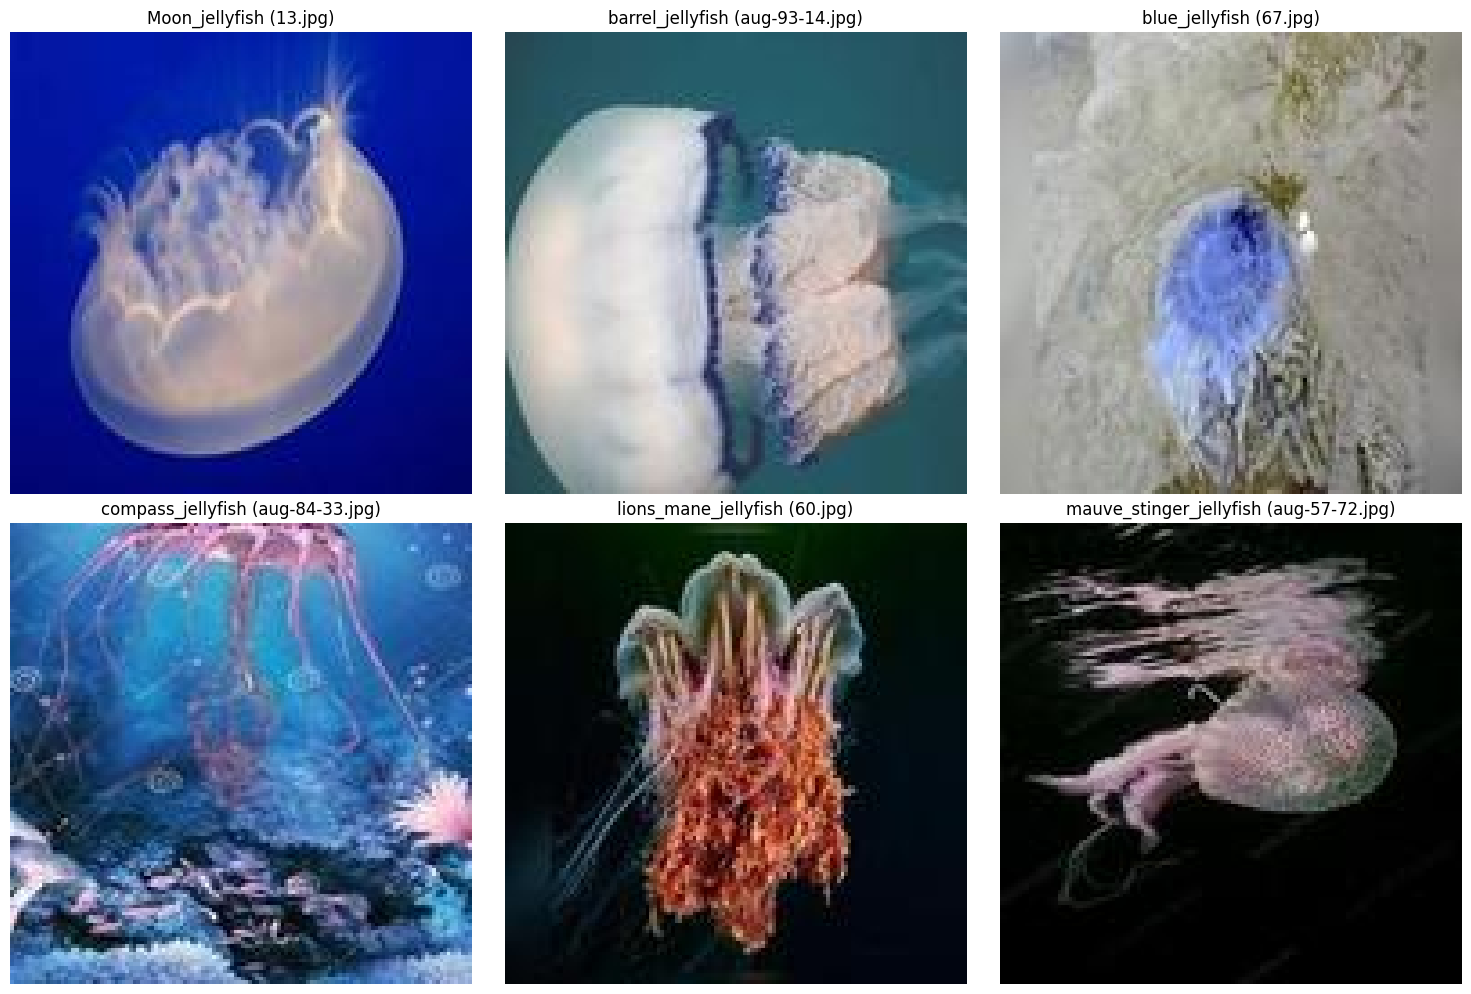

In [9]:
# 실행시 마다 해당 클래스에서 이미지 랜덤 출력
class_labels = list(train_labels.keys())

num_classes = len(class_labels)
num_cols = 3
num_rows = (num_classes + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, class_label in enumerate(class_labels):
    class_dir = os.path.join(train_path, class_label)
    image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    image_file = random.choice(image_files)
    image_path = os.path.join(class_dir, image_file)

    img = mpimg.imread(image_path)
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.title(f"{class_label} ({image_file})")  # 라벨과 파일명 함께 출력
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import PIL
def resize_images_in_folder(folder_path, target_size=(128, 128)):
    """
    폴더 내의 모든 이미지를 지정된 크기로 리사이즈.

    Args:
        folder_path: 이미지가 있는 폴더 경로
        target_size: 리사이즈할 크기 (튜플 형태, (width, height))
    """
    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.png', '.jpeg')):  # 이미지 파일인지 확인
            image_path = os.path.join(folder_path, filename)
            try:
                img = Image.open(image_path)
                resized_img = img.resize(target_size, PIL.Image.LANCZOS)  # 비율 유지하며 리사이즈
                resized_img.save(image_path)  # 원본 이미지 덮어쓰기

                # 리사이즈된 이미지 사이즈 출력
                width, height = resized_img.size
                print(f"{image_path} 리사이즈 완료 - 새로운 사이즈: {width} x {height}")
            except Exception as e:
                print(f"{image_path} 리사이즈 실패: {e}")

# train_path의 하위 폴더들을 순회하며 리사이즈
for class_dir in os.listdir(train_path):
    class_dir_path = os.path.join(train_path, class_dir)
    if os.path.isdir(class_dir_path):
        print(f"{class_dir} 폴더 내 이미지 리사이즈 시작")
        resize_images_in_folder(class_dir_path)
        print(f"{class_dir} 폴더 내 이미지 리사이즈 완료")

Moon_jellyfish 폴더 내 이미지 리사이즈 시작
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/01.jpg 리사이즈 완료 - 새로운 사이즈: 128 x 128
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/02.jpg 리사이즈 완료 - 새로운 사이즈: 128 x 128
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/03.jpg 리사이즈 완료 - 새로운 사이즈: 128 x 128
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/04.jpg 리사이즈 완료 - 새로운 사이즈: 128 x 128
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/05.jpg 리사이즈 완료 - 새로운 사이즈: 128 x 128
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/06.jpg 리사이즈 완료 - 새로운 사이즈: 128 x 128
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train/Moon_jellyfish/08.jpg 리사이

NameError: name 'width' is not defined

In [19]:
def count_images_per_class(folder_path):
    """
    특정 폴더 내의 클래스별 이미지 개수를 셉니다.

    Args:
        folder_path: 이미지가 있는 폴더 경로

    Returns:
        클래스별 이미지 개수를 담은 딕셔너리
    """
    class_counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            class_counts[class_name] = len(os.listdir(class_folder))
    return class_counts

# train_path와 val_path에서 클래스별 이미지 개수 세기
train_counts = count_images_per_class(train_path)
val_counts = count_images_per_class(val_path)

# 데이터프레임 생성
df = pd.DataFrame({'train': train_counts, 'val': val_counts})

# NaN 값을 0으로 채우기
df = df.fillna(0).astype(int)

# 결과 출력
print(f"원본 이미지 개수:\n{df}")

원본 이미지 개수:
                         train  val
Moon_jellyfish              47    6
barrel_jellyfish            41    5
blue_jellyfish              55    7
compass_jellyfish           57    7
lions_mane_jellyfish        61    7
mauve_stinger_jellyfish     58    7


In [22]:
def merge_and_split_data(train_path, val_path, target_path, split_ratio=0.2):
    """
    train 데이터와 val 데이터를 합치고 중복을 확인한 후 섞어서 train과 val로 다시 나눕니다.

    Args:
        train_path: train 데이터 경로
        val_path: val 데이터 경로
        target_path: 합쳐진 데이터를 저장할 경로
        split_ratio: val 데이터 비율 (기본값: 0.2)
    """

    # 1. train 데이터와 val 데이터를 합치기
    merged_path = os.path.join(target_path, "merged_data")
    os.makedirs(merged_path, exist_ok=True)  # merged_path 폴더 생성

    for class_name in os.listdir(train_path):
        class_train_path = os.path.join(train_path, class_name)
        class_val_path = os.path.join(val_path, class_name)
        class_merged_path = os.path.join(merged_path, class_name)
        os.makedirs(class_merged_path, exist_ok=True)  # 클래스별 폴더 생성

        # train 데이터 복사
        for filename in os.listdir(class_train_path):
            shutil.copy(os.path.join(class_train_path, filename), class_merged_path)

        # val 데이터 복사
        for filename in os.listdir(class_val_path):
            shutil.copy(os.path.join(class_val_path, filename), class_merged_path)

    # 2. 중복 데이터 확인 (파일 이름 기준)
    all_files = []
    for class_name in os.listdir(merged_path):
        class_path = os.path.join(merged_path, class_name)
        for filename in os.listdir(class_path):
            all_files.append(os.path.join(class_name, filename))  # 클래스/파일명 형태로 저장

    duplicates = pd.Series(all_files).duplicated().sum()
    if duplicates > 0:
        print(f"중복된 파일이 {duplicates}개 있습니다. 확인해주세요.")

    # 3. 데이터 섞어서 train과 val로 다시 나누기
    train_data, val_data = train_test_split(all_files, test_size=split_ratio, random_state=42)

    # train, val 폴더 생성 및 데이터 복사
    train_target_path = os.path.join(target_path, "train")
    val_target_path = os.path.join(target_path, "val")
    os.makedirs(train_target_path, exist_ok=True)
    os.makedirs(val_target_path, exist_ok=True)

    for data, target_path in [(train_data, train_target_path), (val_data, val_target_path)]:
        for item in data:
            class_name, filename = os.path.split(item)
            class_path = os.path.join(target_path, class_name)
            os.makedirs(class_path, exist_ok=True)
            shutil.copy(os.path.join(merged_path, item), class_path)

    print("데이터 합치기, 중복 확인, 분할 완료!")

# 사용 예시
target_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/merged_dataset"  # 데이터를 저장할 경로
merge_and_split_data(train_path, val_path, target_path)

데이터 합치기, 중복 확인, 분할 완료!


In [24]:
# 데이터 경로 수정
train_path = os.path.join(target_path, "train")
val_path = os.path.join(target_path, "val")

# train_path와 val_path에서 클래스별 이미지 개수 세기
train_counts = count_images_per_class(train_path)
val_counts = count_images_per_class(val_path)

# 데이터프레임 생성
df = pd.DataFrame({'train': train_counts, 'val': val_counts})

# NaN 값을 0으로 채우기
df = df.fillna(0).astype(int)

# 결과 출력
print(f"원본 이미지 개수:\n{df}")

원본 이미지 개수:
                         train  val
mauve_stinger_jellyfish     54   11
compass_jellyfish           53   11
barrel_jellyfish            32   14
Moon_jellyfish              41   12
blue_jellyfish              51   11
lions_mane_jellyfish        55   13


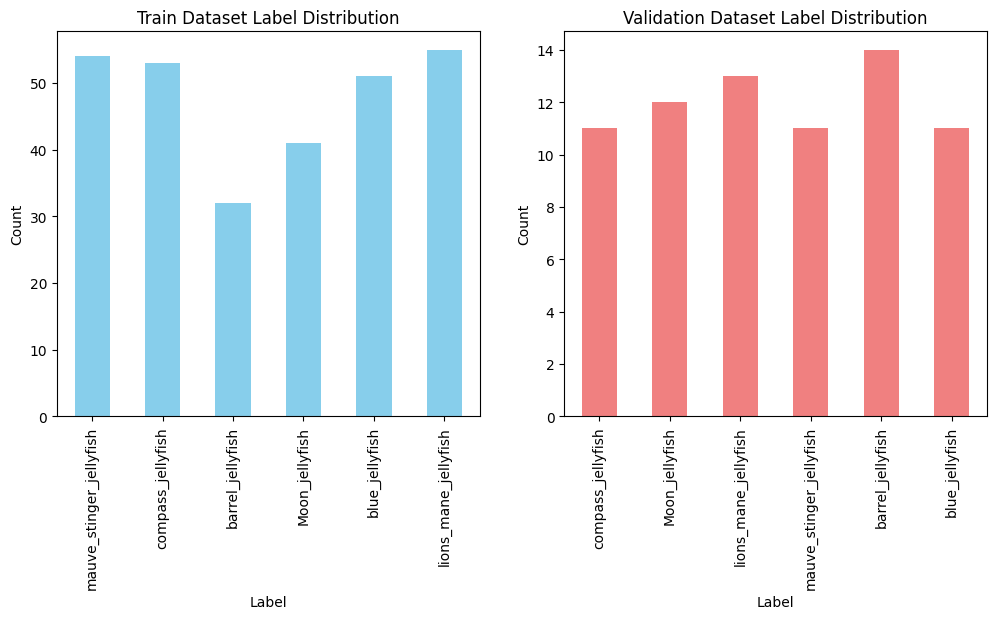

In [30]:
# Train & Validation 라벨 개수 집계
train_counts = count_labels(train_path)
val_counts = count_labels(val_path)

# 데이터프레임 변환
df_train = pd.DataFrame(list(train_counts.items()), columns=["Label", "Count"])
df_val = pd.DataFrame(list(val_counts.items()), columns=["Label", "Count"])

# 라벨 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_train.plot(kind="bar", x="Label", y="Count", ax=axes[0], color="skyblue", legend=False)
axes[0].set_title("Train Dataset Label Distribution")
axes[0].set_ylabel("Count")

df_val.plot(kind="bar", x="Label", y="Count", ax=axes[1], color="lightcoral", legend=False)
axes[1].set_title("Validation Dataset Label Distribution")
axes[1].set_ylabel("Count")

plt.show()